In [1]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load data
optimiser_history = (
    pl.read_csv("data/training-history.csv")
    .with_columns(iteration = pl.col("Target").cum_count())
    .rename({"Target":"SC12_coinc*events_after_hot_dump"})
)
print(optimiser_history)

shape: (129, 6)
┌────────────────┬────────────────┬───────────────┬───────────────┬────────────────────┬───────────┐
│ ELENA_H_OFFSET ┆ ELENA_V_OFFSET ┆ ELENA_H_ANGLE ┆ ELENA_V_ANGLE ┆ SC12_coinc*events_ ┆ iteration │
│ ---            ┆ ---            ┆ ---           ┆ ---           ┆ after_hot_du…      ┆ ---       │
│ f64            ┆ f64            ┆ f64           ┆ f64           ┆ ---                ┆ u32       │
│                ┆                ┆               ┆               ┆ f64                ┆           │
╞════════════════╪════════════════╪═══════════════╪═══════════════╪════════════════════╪═══════════╡
│ -10.0          ┆ 0.0            ┆ 0.0           ┆ 0.0           ┆ -1315.714286       ┆ 1         │
│ -17.914371     ┆ -6.369173      ┆ 3.831815      ┆ 2.874548      ┆ 161751.428571      ┆ 2         │
│ -3.952348      ┆ 0.310483       ┆ -0.898414     ┆ 6.005886      ┆ 171713.857143      ┆ 3         │
│ -17.118702     ┆ -4.110867      ┆ 3.008235      ┆ 6.821051      ┆ 134707.

In [3]:
print(optimiser_history.filter(pl.col("SC12_coinc*events_after_hot_dump")==pl.col("SC12_coinc*events_after_hot_dump").max()))

shape: (1, 6)
┌────────────────┬────────────────┬───────────────┬───────────────┬────────────────────┬───────────┐
│ ELENA_H_OFFSET ┆ ELENA_V_OFFSET ┆ ELENA_H_ANGLE ┆ ELENA_V_ANGLE ┆ SC12_coinc*events_ ┆ iteration │
│ ---            ┆ ---            ┆ ---           ┆ ---           ┆ after_hot_du…      ┆ ---       │
│ f64            ┆ f64            ┆ f64           ┆ f64           ┆ ---                ┆ u32       │
│                ┆                ┆               ┆               ┆ f64                ┆           │
╞════════════════╪════════════════╪═══════════════╪═══════════════╪════════════════════╪═══════════╡
│ -6.692558      ┆ 5.0            ┆ 5.0           ┆ 5.866559      ┆ 379865.857143      ┆ 113       │
└────────────────┴────────────────┴───────────────┴───────────────┴────────────────────┴───────────┘


<Axes: xlabel='iteration', ylabel='SC12_coinc*events_after_hot_dump'>

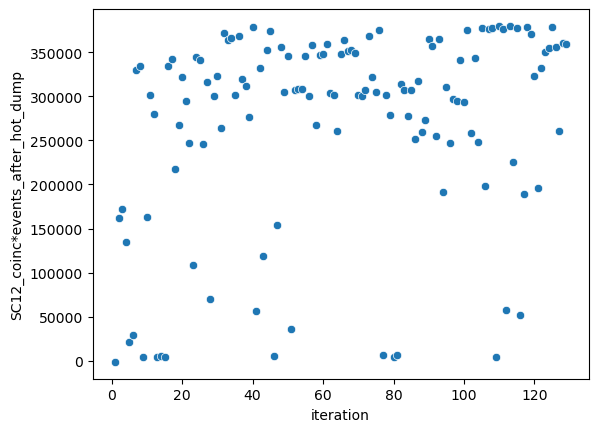

In [4]:
sns.scatterplot(optimiser_history,x="iteration",y="SC12_coinc*events_after_hot_dump")

In [5]:
norm = plt.Normalize(optimiser_history["SC12_coinc*events_after_hot_dump"].min(), optimiser_history["SC12_coinc*events_after_hot_dump"].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])

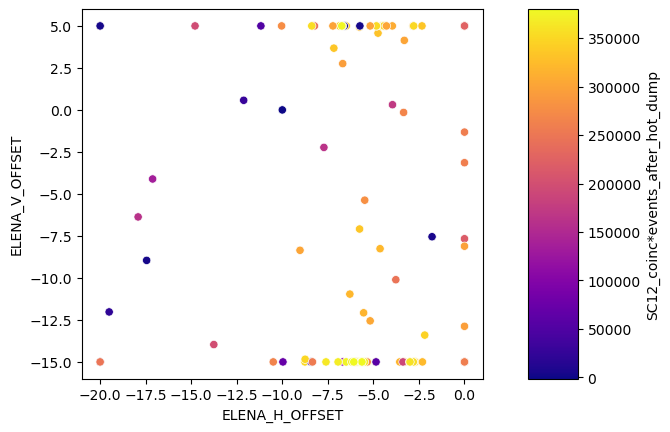

In [6]:
fig,ax = plt.subplots(1,2,width_ratios=(8,1))
sns.scatterplot(optimiser_history,x="ELENA_H_OFFSET",y="ELENA_V_OFFSET",hue="SC12_coinc*events_after_hot_dump",palette="plasma",ax=ax[0],legend=False)

# Remove the legend and add a colorbar
fig.colorbar(sm,ax[1],label="SC12_coinc*events_after_hot_dump")

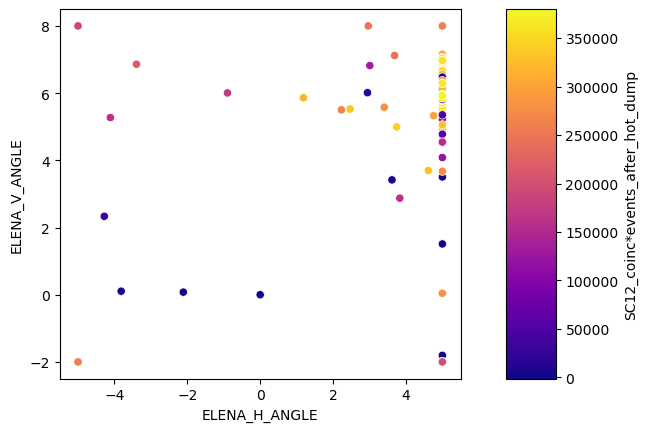

In [7]:
fig,ax = plt.subplots(1,2,width_ratios=(8,1))
sns.scatterplot(optimiser_history,x="ELENA_H_ANGLE",y="ELENA_V_ANGLE",hue="SC12_coinc*events_after_hot_dump",palette="plasma",ax=ax[0],legend=False)

# Remove the legend and add a colorbar
fig.colorbar(sm,ax[1],label="SC12_coinc*events_after_hot_dump")

In [19]:
x1 = [i for i in range(10)]
x2 = [i for i in range(5)]
x3 = None

for idx,ix in enumerate([x1,x2,x3]):
    df = pl.DataFrame({'x':[ix,None]})
    df.write_parquet(f"C:/ALPACA/analysis/ELENA_beam_steering/data/tmp/x{idx}.parquet")
    print(pl.read_parquet_schema(f"C:/ALPACA/analysis/ELENA_beam_steering/data/tmp/x{idx}.parquet"))
    print(df)

df = pl.concat(pl.read_parquet("C:/ALPACA/analysis/ELENA_beam_steering/data/tmp/x*.parquet"))
print(df)

{'x': List(Int64)}
shape: (2, 1)
┌─────────────┐
│ x           │
│ ---         │
│ list[i64]   │
╞═════════════╡
│ [0, 1, … 9] │
│ null        │
└─────────────┘
{'x': List(Int64)}
shape: (2, 1)
┌─────────────┐
│ x           │
│ ---         │
│ list[i64]   │
╞═════════════╡
│ [0, 1, … 4] │
│ null        │
└─────────────┘
{'x': Null}
shape: (2, 1)
┌──────┐
│ x    │
│ ---  │
│ null │
╞══════╡
│ null │
│ null │
└──────┘


SchemaError: data type mismatch for column x: incoming: Null != target: List(Int64)